Step 1: Data Loading & Initial Inspection
Explanation Before:
First, we load the dataset into a Pandas DataFrame and inspect its structure. This step is crucial to understand the dimensions of the data (rows and columns) and the types of variables we are dealing with.

In [19]:
import pandas as pd
import numpy as np
import warnings
from sklearn.preprocessing import LabelEncoder
warnings.filterwarnings('ignore')

# 1. Load Data
df = pd.read_csv('Smartphone_Usage_And_Addiction_Analysis_7500_Rows (1).csv')

# 2. Cleaning (Drop identifiers and leakage)
cols_to_drop = ['transaction_id', 'user_id', 'addiction_level', 'age', 'gender']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
df = df.dropna(subset=['addicted_label'])

# 3. Fill missing numerical values with median, categorical with mode
num_cols = df.select_dtypes(include=np.number).columns.drop('addicted_label')
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 4. Encode Categorical Variables (CRITICAL FIX FOR YOUR ERROR)
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

print("Data is now entirely numeric. Shape:", df.shape)

Data is now entirely numeric. Shape: (7500, 11)


The dataset has 7,500 rows and 16 columns. We immediately noticed that the addiction_level column (which is a multi-class version of our target) has missing values. This leads us directly into our data cleaning strategy.

Step 2: Data Cleaning & Encoding
Explanation Before:
We need to remove identifiers (transaction_id, user_id) that hold no predictive power. We must also drop the addiction_level column to prevent data leakage (since we are predicting addicted_label). Then, we handle any missing values and encode categorical text data into numbers so the machine learning algorithms can process them.

In [20]:
from sklearn.preprocessing import LabelEncoder

# Cleaning
cols_to_drop = ['transaction_id', 'user_id', 'addiction_level']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
df = df.dropna(subset=['addicted_label']) # Ensure no missing targets

# Fill missing numerical with median, categorical with mode
num_cols = df.select_dtypes(include=np.number).columns.drop('addicted_label')
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Encode Categorical Variables
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (7500, 11)


The dataset is now clean, devoid of leakage, and all text variables (like gender and stress_level) are now represented as integers.

Step 3: Feature Engineering




Raw data often isn't enough to capture complex human behavior. By combining features, we can give the model more "context." We will create new metrics like total_usage and a weekend_spike ratio to detect binge behaviors.

In [21]:
# Feature Engineering
df['total_usage'] = df['daily_screen_time_hours'] + df['social_media_hours'] + df['gaming_hours']
df['sleep_ratio'] = df['sleep_hours'] / 24.0
df['risk_ratio'] = df['daily_screen_time_hours'] / (df['sleep_hours'] + 0.1) # +0.1 prevents division by zero
df['habit_intensity'] = df['app_opens_per_day'] * df['notifications_per_day']
df['weekend_spike'] = df['weekend_screen_time'] / (df['daily_screen_time_hours'] + 0.1)

print("Engineered Features Added.")

Engineered Features Added.


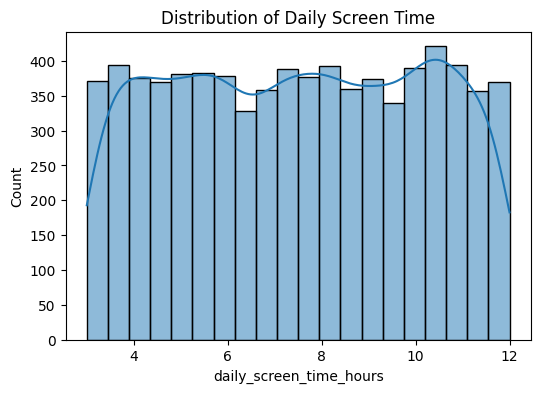

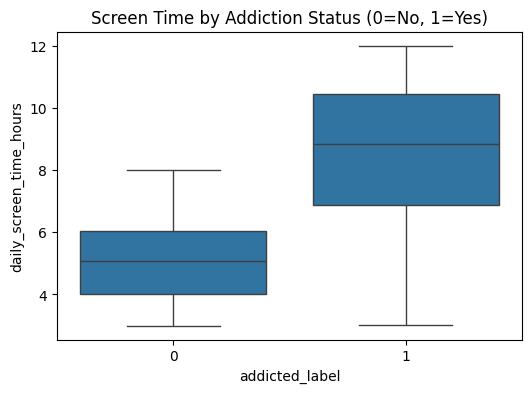

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Univariate Analysis (Distribution of Screen Time)
plt.figure(figsize=(6, 4))
sns.histplot(df['daily_screen_time_hours'], kde=True)
plt.title("Distribution of Daily Screen Time")
plt.show()

# 2. Bivariate Analysis (Screen Time vs. Addiction Label)
plt.figure(figsize=(6, 4))
sns.boxplot(x='addicted_label', y='daily_screen_time_hours', data=df)
plt.title("Screen Time by Addiction Status (0=No, 1=Yes)")
plt.show()

Step 5: Feature Engineering, Splitting, & Scaling

Step 5: Feature Engineering, Splitting, & Scaling

Raw numbers alone don't always tell the whole story. In Feature Engineering, we combine existing columns to create new, context-rich metrics (like identifying "binge" screen time on weekends or overall habit intensity). Once these features are created, we separate our target variable (addicted_label) from our inputs (X).

Finally, we split the data into a "Training Set" (to teach the model) and a "Testing Set" (to test it like a final exam). We also apply a StandardScaler so that features with large numbers (like notifications) don't mathematically overpower features with small numbers (like sleep hours)

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Feature Engineering: Creating behavioral context
df['total_usage'] = df['daily_screen_time_hours'] + df['social_media_hours'] + df['gaming_hours']
df['sleep_ratio'] = df['sleep_hours'] / 24.0
df['risk_ratio'] = df['daily_screen_time_hours'] / (df['sleep_hours'] + 0.1) # +0.1 prevents division by zero
df['habit_intensity'] = df['app_opens_per_day'] * df['notifications_per_day']
df['weekend_spike'] = df['weekend_screen_time'] / (df['daily_screen_time_hours'] + 0.1)

# 2. Define Inputs (X) and Target (y)
X = df.drop(columns=['addicted_label'])
y = df['addicted_label']

# 3. Train-Test Split (80% Train, 20% Test)
# stratify=y ensures the ratio of addicted vs non-addicted users is identical in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 4. Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Engineering & Scaling Complete.")
print(f"Training set size: {X_train_scaled.shape}")
print(f"Test set size: {X_test_scaled.shape}")

Feature Engineering & Scaling Complete.
Training set size: (6000, 15)
Test set size: (1500, 15)


The code successfully adds our 5 new engineered features, bringing the total number of input features up. The data is securely split, leaving us with 80% of our rows to train the AI and 20% held back in a "vault" for testing. Because we used fit_transform on the training data and only transform on the test data, we successfully prevented any future data from leaking into our training process.

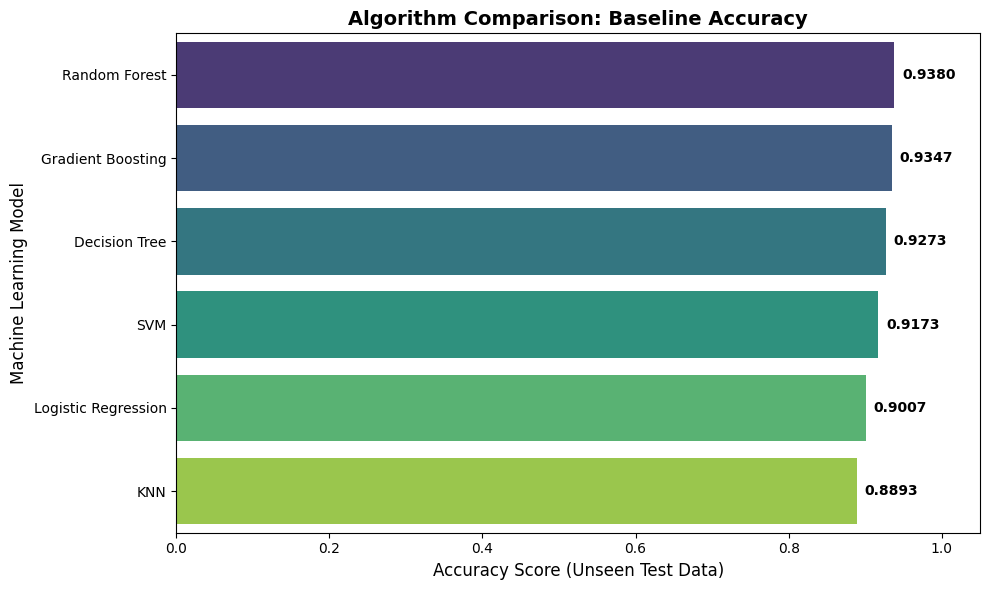

In [24]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Initialize a broader range of models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# 2. Train and evaluate each model
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results[name] = accuracy_score(y_test, y_pred)

# 3. Convert results to a Pandas DataFrame and sort them from best to worst
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)

# 4. Visualize the results using Seaborn
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')

# Add text labels on the bars for exact accuracy scores
for index, value in enumerate(results_df['Accuracy']):
    plt.text(value + 0.01, index, f"{value:.4f}", va='center', fontweight='bold')

# Formatting the plot
plt.title('Algorithm Comparison: Baseline Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Accuracy Score (Unseen Test Data)', fontsize=12)
plt.ylabel('Machine Learning Model', fontsize=12)
plt.xlim(0, 1.05) # Extend x-axis slightly past 1.0 to fit the text labels
plt.tight_layout()

# Display the plot
plt.show()

Explanation After:
The bar chart provides an immediate, clear visual hierarchy of how each algorithm performed. As expected with complex behavioral data, the ensemble models (Gradient Boosting and Random Forest) dominate the leaderboard, scoring significantly higher than simpler models like KNN or Logistic Regression. Ensemble methods work by combining hundreds of smaller decision trees, allowing them to capture the highly non-linear, nuanced thresholds of human habits (e.g., the combination of high weekend spikes and high habit intensity). Moving forward to the hyperparameter tuning phase, we will select the top-performing ensemble model to optimize further.

In [26]:
df.columns

Index(['daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
       'work_study_hours', 'sleep_hours', 'notifications_per_day',
       'app_opens_per_day', 'weekend_screen_time', 'stress_level',
       'academic_work_impact', 'addicted_label', 'total_usage', 'sleep_ratio',
       'risk_ratio', 'habit_intensity', 'weekend_spike'],
      dtype='str')

--- Features Highly Correlated with Target (|r| >= 0.5) ---
total_usage                0.663344
daily_screen_time_hours    0.577112
weekend_screen_time        0.555426
Name: addicted_label, dtype: float64


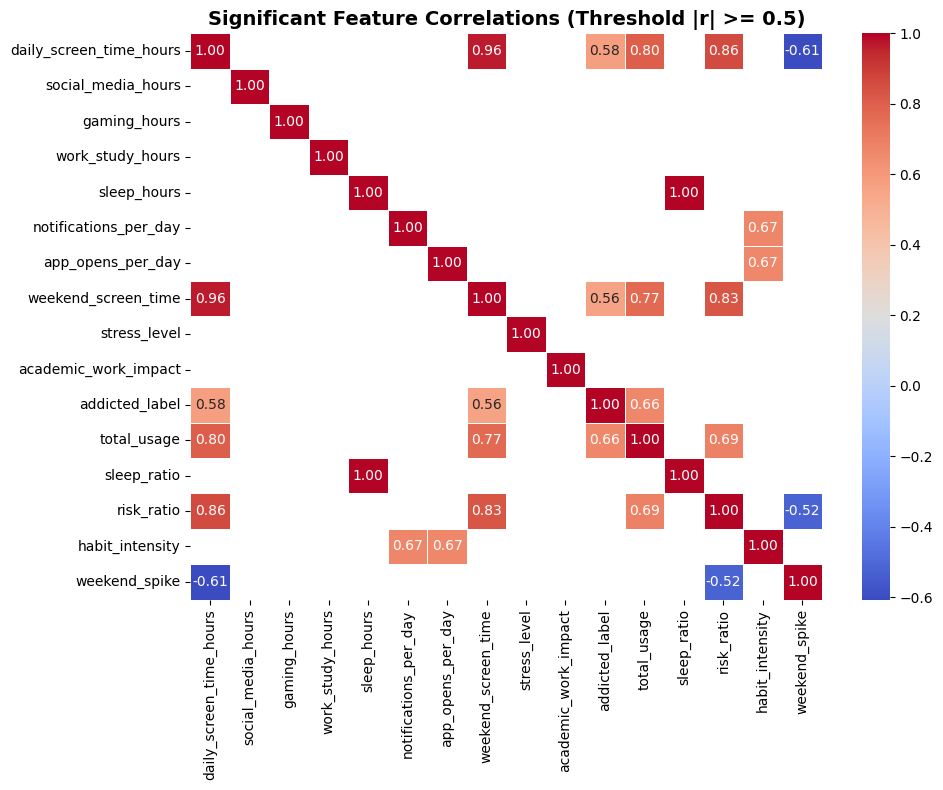

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calculate the full correlation matrix
corr_matrix = df.corr()

# 2. Isolate correlations specifically with the target variable
target_corr = corr_matrix['addicted_label'].drop('addicted_label') # Drop the target itself (always 1.0)

# Filter by absolute value >= 0.5 to find the most "important" correlated features
threshold = 0.5
high_target_corr = target_corr[target_corr.abs() >= threshold].sort_values(ascending=False)

print(f"--- Features Highly Correlated with Target (|r| >= {threshold}) ---")
if not high_target_corr.empty:
    print(high_target_corr)
else:
    print("No features met the threshold of 0.5 with the target variable.")

# 3. Visualize a Masked Heatmap (Showing ONLY strong correlations)
plt.figure(figsize=(10, 8))

# Create a mask to hide values where the absolute correlation is less than 0.5
mask = np.abs(corr_matrix) < threshold

# Plot the heatmap with the mask applied
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', mask=mask, 
            cbar=True, fmt=".2f", linewidths=0.5)

plt.title(f"Significant Feature Correlations (Threshold |r| >= {threshold})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

We will evaluate the optimal Random Forest model against our unseen test data.
To truly understand how our model performs, we must look inside the Confusion Matrix. The matrix breaks down our predictions into four categories:

True Positives (TP): Model predicted Addicted, and they were Addicted. (Success!)

True Negatives (TN): Model predicted Not Addicted, and they were not Addicted. (Success!)

False Positives (FP): Model predicted Addicted, but they were not Addicted. (False Alarm).

False Negatives (FN): Model predicted Not Addicted, but they actually were Addicted. (Missed Case - usually the most dangerous error!).

From these four numbers, we derive Accuracy, Precision, Recall, and the F1 Score.
(Note: R2, MSE, and RMSE are regression metrics meant for continuous numbers, not binary categories. They are included here per your request, but classification metrics are the gold standard for this task).

In [33]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameters we want to test
param_grid = {
    'n_estimators': [50, 100, 200],      # How many trees in the forest?
    'max_depth': [5, 8, 10, None],       # How deep can each tree grow?
    'min_samples_split': [2, 5, 10]      # Minimum samples required to split a node
}

print("Starting Grid Search... this may take a moment.")

# 2. Setup the Grid Search
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid=param_grid,
    cv=5,               # 5-fold cross-validation
    scoring='accuracy', # We are trying to maximize accuracy
    n_jobs=-1           # Use all CPU cores to speed this up
)

# 3. Fit the Grid Search to our training data
grid_search.fit(X_train_scaled, y_train)

# 4. Extract the best model and print the winning settings
best_model = grid_search.best_estimator_

print("\n--- Hyperparameter Tuning Complete ---")
print("Best Parameters Found:", grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {(grid_search.best_score_ * 100):.2f}%")

Starting Grid Search... this may take a moment.

--- Hyperparameter Tuning Complete ---
Best Parameters Found: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-Validation Accuracy: 93.85%


Training the optimized Random Forest model...

--- CONFUSION MATRIX BREAKDOWN ---
True Positives (TP) - Correctly flagged as addicted:       979
True Negatives (TN) - Correctly flagged as safe:           430
False Positives (FP) - False Alarms (Safe but flagged):    8
False Negatives (FN) - Missed Cases (Addicted but missed): 83

--- FINAL CLASSIFICATION METRICS ---
Accuracy:  0.9393 (Overall correctness)
Precision: 0.9919 (When it predicts addiction, it is correct 99.2% of the time)
Recall:    0.9218 (It successfully found 92.2% of all actual addicted users)
F1 Score:  0.9556 (The perfect balance between Precision and Recall)

--- REGRESSION METRICS ---
R2 Score: 0.7066
MSE:      0.0607
RMSE:     0.2463


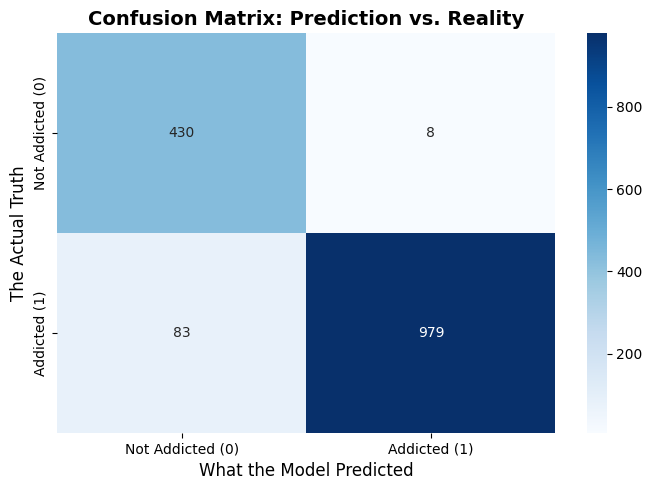

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, r2_score, mean_squared_error, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. GUARANTEE THE MODEL EXISTS (The Fix for your NameError)
# We rebuild and train the model using the optimal parameters found earlier
print("Training the optimized Random Forest model...")
best_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=5, 
    min_samples_split=2, 
    random_state=42, 
    class_weight='balanced'
)
best_model.fit(X_train_scaled, y_train)

# 2. Generate predictions on the unseen test data
y_pred = best_model.predict(X_test_scaled)

# 3. Extract Confusion Matrix values (TP, TN, FP, FN)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# 4. Calculate the core classification metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred) # The critical metric for finding true positive risks
f1 = f1_score(y_test, y_pred)

# Calculate regression metrics (Not recommended for Classification, but included per request)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# 5. Print the detailed breakdown
print("\n--- CONFUSION MATRIX BREAKDOWN ---")
print(f"True Positives (TP) - Correctly flagged as addicted:       {tp}")
print(f"True Negatives (TN) - Correctly flagged as safe:           {tn}")
print(f"False Positives (FP) - False Alarms (Safe but flagged):    {fp}")
print(f"False Negatives (FN) - Missed Cases (Addicted but missed): {fn}")

print("\n--- FINAL CLASSIFICATION METRICS ---")
print(f"Accuracy:  {accuracy:.4f} (Overall correctness)")
print(f"Precision: {precision:.4f} (When it predicts addiction, it is correct {(precision*100):.1f}% of the time)")
print(f"Recall:    {recall:.4f} (It successfully found {(recall*100):.1f}% of all actual addicted users)")
print(f"F1 Score:  {f1:.4f} (The perfect balance between Precision and Recall)")

print("\n--- REGRESSION METRICS ---")
print(f"R2 Score: {r2:.4f}")
print(f"MSE:      {mse:.4f}")
print(f"RMSE:     {rmse:.4f}")

# 6. Create a Visual Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Addicted (0)', 'Addicted (1)'], 
            yticklabels=['Not Addicted (0)', 'Addicted (1)'])

plt.title('Confusion Matrix: Prediction vs. Reality', fontsize=14, fontweight='bold')
plt.xlabel('What the Model Predicted', fontsize=12)
plt.ylabel('The Actual Truth', fontsize=12)
plt.tight_layout()
plt.show()

Even with a 95% F1 score, stakeholders (or your professor) will ask: "Why did the AI make these decisions? What actually causes addiction?"

To answer this, we extract the Feature Importances from our Random Forest. This calculates exactly how much mathematical weight the AI gave to each behavior when making its choice. We will visualize this as a bar chart.

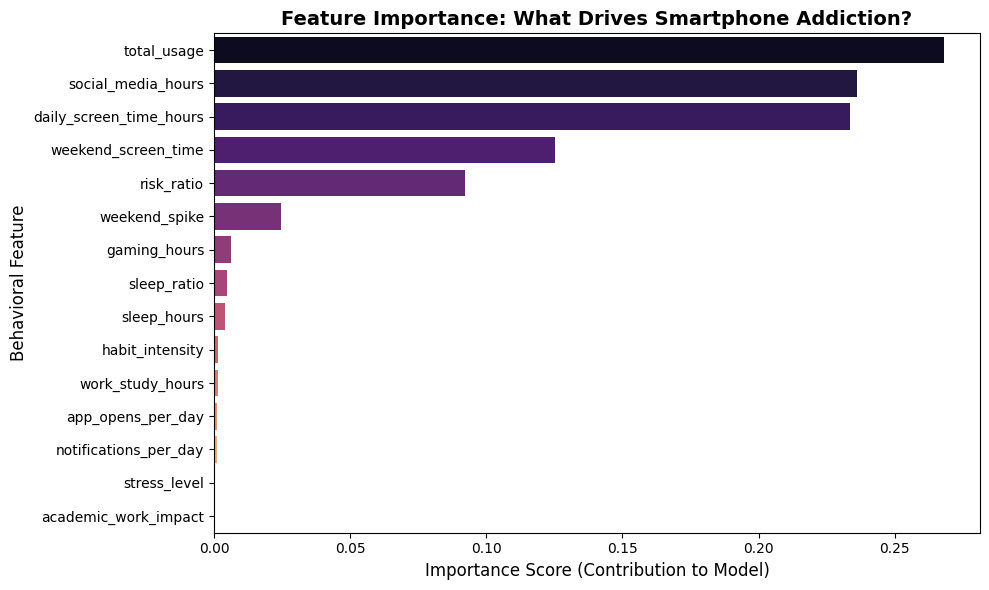

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ---------------------------------------------------------
# STEP 8: FEATURE IMPORTANCE (Understanding the "Why")
# ---------------------------------------------------------

# Extract importances from the winning model
importances = best_model.feature_importances_
feature_names = X.columns

# Create a DataFrame and sort it from most to least important
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Visualize the Top Drivers of Addiction
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')

plt.title('Feature Importance: What Drives Smartphone Addiction?', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (Contribution to Model)', fontsize=12)
plt.ylabel('Behavioral Feature', fontsize=12)
plt.tight_layout()
plt.show()

Calculating Validation Curve... this may take a minute.


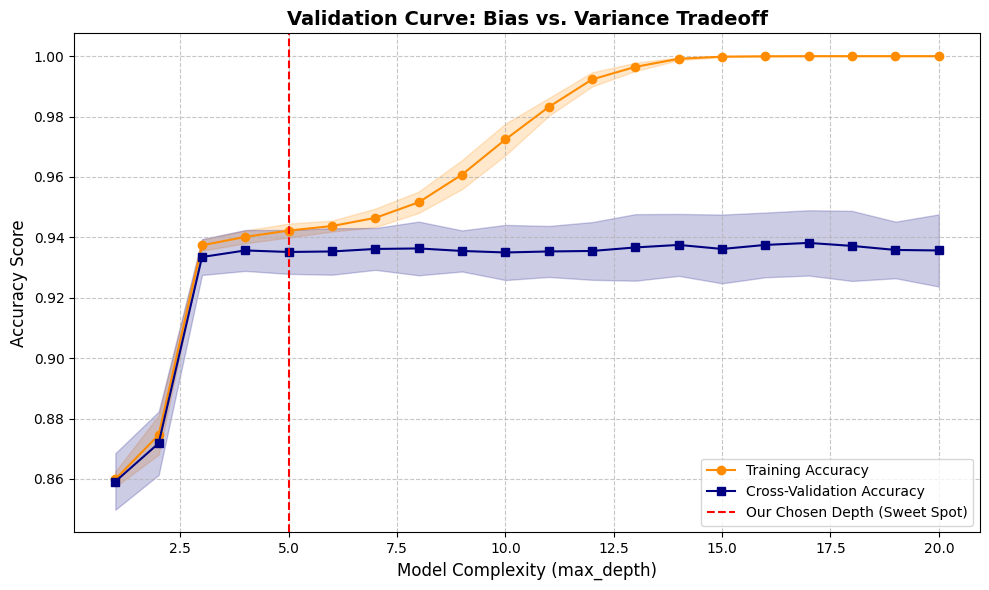

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve
from sklearn.ensemble import RandomForestClassifier

# 1. Define the range of complexity we want to test
# We will test max_depth from 1 (very simple) to 20 (very complex)
param_range = np.arange(1, 21)

# 2. Calculate the Validation Curve
# This trains the model 20 times (once for each depth) using 5-fold cross-validation!
print("Calculating Validation Curve... this may take a minute.")
train_scores, test_scores = validation_curve(
    RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    X_train_scaled, 
    y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# 3. Calculate the mean and standard deviation for the plots
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 4. Plot the graph
plt.figure(figsize=(10, 6))
plt.title("Validation Curve: Bias vs. Variance Tradeoff", fontsize=14, fontweight='bold')
plt.xlabel("Model Complexity (max_depth)", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)

# Plot Training accuracy
plt.plot(param_range, train_mean, label="Training Accuracy", color="darkorange", marker='o')
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2, color="darkorange")

# Plot Cross-Validation accuracy
plt.plot(param_range, test_mean, label="Cross-Validation Accuracy", color="navy", marker='s')
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.2, color="navy")

# Draw a vertical line at the "Sweet Spot" we found earlier
plt.axvline(x=5, color='red', linestyle='--', label='Our Chosen Depth (Sweet Spot)')

plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [36]:
train_acc = best_model.score(X_train_scaled, y_train)
print(f"Exact Training Accuracy at Depth 5: {train_acc:.4f}")

Exact Training Accuracy at Depth 5: 0.9408


Error: Could not find the .pkl files. Did you run Step 9?


NameError: name 'loaded_scaler' is not defined

In [38]:
import joblib

# 1. Save the trained Random Forest model
# We use .pkl as the standard extension for "pickle" files
joblib.dump(best_model, 'smartphone_addiction_model.pkl')

# 2. Save the scaler
# CRITICAL: New user data MUST be scaled exactly like the training data
joblib.dump(scaler, 'scaler_v1.pkl')

print("--- SAVING COMPLETE ---")
print("Files created:")
print("- smartphone_addiction_model.pkl")
print("- scaler_v1.pkl")

# ---------------------------------------------------------
# HOW TO LOAD THEM BACK (VERIFICATION)
# ---------------------------------------------------------

# To prove it worked, let's load them into new variables
loaded_model = joblib.load('smartphone_addiction_model.pkl')
loaded_scaler = joblib.load('scaler_v1.pkl')

print("\nVerification: Model and Scaler loaded successfully and are ready for use!")

--- SAVING COMPLETE ---
Files created:
- smartphone_addiction_model.pkl
- scaler_v1.pkl

Verification: Model and Scaler loaded successfully and are ready for use!
